In [14]:
# ==========================================
# 1. IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


In [ ]:
# Display first 10 rows

df.head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.0,33.6,49.0,8.3,...,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.596,57.1
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.2,23.5,50.8,9.5,...,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.687,31.6
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.2,29.0,64.9,7.9,...,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.697,54.2
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.7,33.4,46.8,7.9,...,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.103,54.7
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,...,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7


In [ ]:
# Display last 5 rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Statistical summary of numerical columns

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
# Column names

print("Columns in the dataset:")

for column in df.columns:
    print(column)

Columns in the dataset:
Farm_ID
State
District
Crop
Season
Farm_Area_Hectares
Rainfall_mm
Avg_Temperature_C
Humidity_pct
Sunlight_Hours_Day
Soil_pH
Soil_Moisture_pct
Nitrogen_kg_ha
Phosphorus_kg_ha
Potassium_kg_ha
Irrigation_Method
Fertilizer_kg_ha
Pesticide_Litre_ha
Seed_Quality_Score
Yield_Tonnes_Ha
Production_Tonnes
Market_Price_INR_Tonne
Total_Cost_INR
Revenue_INR
Profit_INR
Water_Used_m3
Water_Efficiency_t_per_1000m3
Disease_Pest_Risk_pct


In [ ]:
# ==========================================
# 3. CHECK MISSING VALUES
# ==========================================

missing_values = df.isnull().sum()

print(missing_values)

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Values,Missing Percentage
Farm_ID,0,0.0
State,0,0.0
District,0,0.0
Crop,0,0.0
Season,0,0.0
Farm_Area_Hectares,0,0.0
Rainfall_mm,48,1.2
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0
Sunlight_Hours_Day,0,0.0


In [ ]:
# ==========================================
# CHECK DUPLICATES
# ==========================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (4000, 28)


In [ ]:
# ==========================================
# SEASON DISTRIBUTION
# ==========================================

print(df["Season"].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [ ]:
print(df["Crop"].value_counts())

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [ ]:
print(df["State"].value_counts())

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


In [ ]:
print(df["Irrigation_Method"].value_counts())

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
# ==========================================
# CLEAN CATEGORICAL COLUMNS
# ==========================================

categorical_columns = [
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method"
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()

print("Categorical columns cleaned.")

Categorical columns cleaned.


In [ ]:
df[categorical_columns].head()

,State,District,Crop,Season,Irrigation_Method
0,Andhra Pradesh,Rajkot,Wheat,Kharif,Drip
1,Maharashtra,Nalgonda,Maize,Kharif,Flood
2,Telangana,Warangal,Pulses,Rabi,Drip
3,Telangana,Indore,Rice,Kharif,Rainfed
4,Karnataka,Ludhiana,Maize,Zaid,Flood


In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
# ==========================================
# SEASON-WISE PERFORMANCE
# ==========================================

season_summary = df.groupby("Season").agg({
    "Farm_Area_Hectares": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_summary

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,7.94,852.08,28.45,5.64,46.31,178914.65,6102.20,54.47
Rabi,7.75,436.00,23.49,5.08,41.49,87689.47,5846.99,40.48
Zaid,8.09,299.42,31.04,4.67,38.89,-24804.82,6419.89,38.22


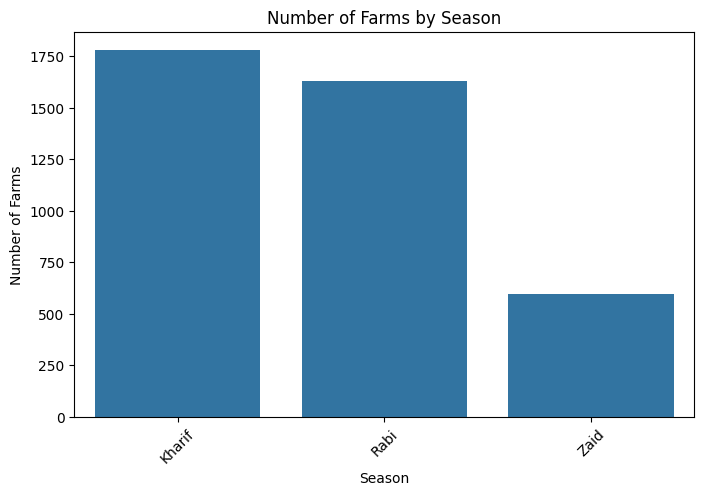

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Season")

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.xticks(rotation=45)
plt.show()

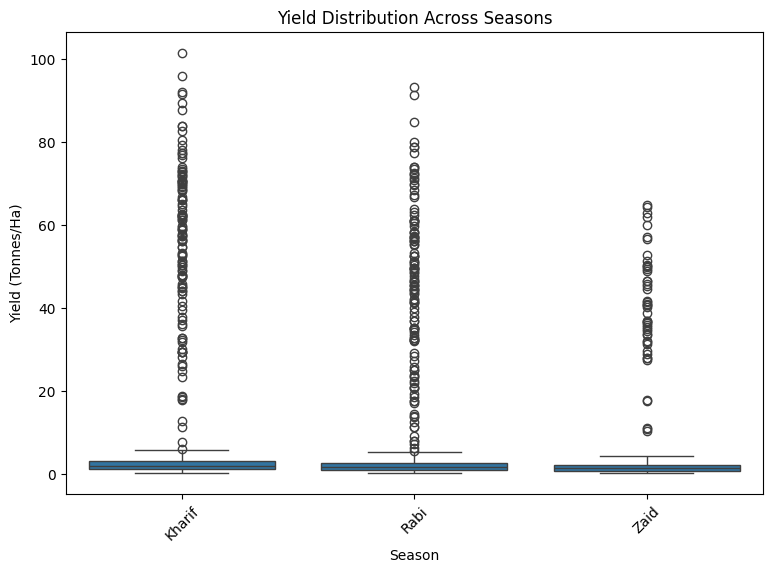

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(season_yield)

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


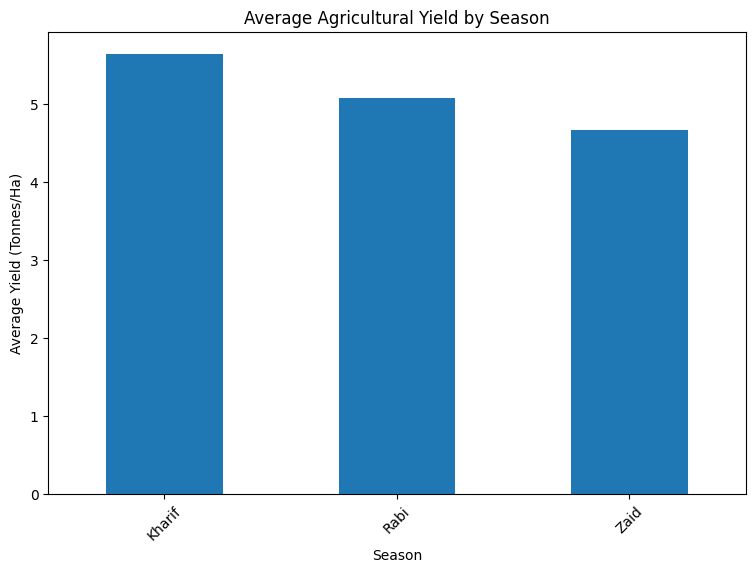

In [ ]:
plt.figure(figsize=(9,6))

season_yield.plot(kind="bar")

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
season_production = (
    df.groupby("Season")["Production_Tonnes"]
    .mean()
    .sort_values(ascending=False)
)

print(season_production)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


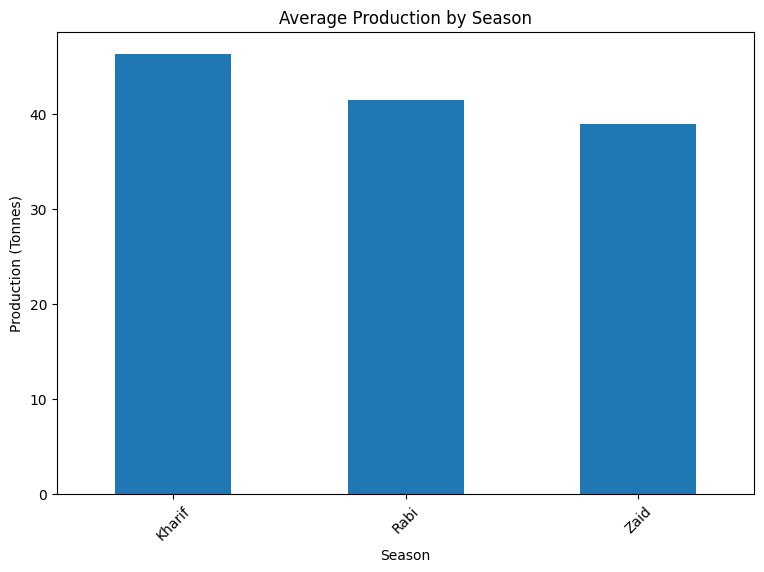

In [ ]:
plt.figure(figsize=(9,6))

season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
season_profit = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


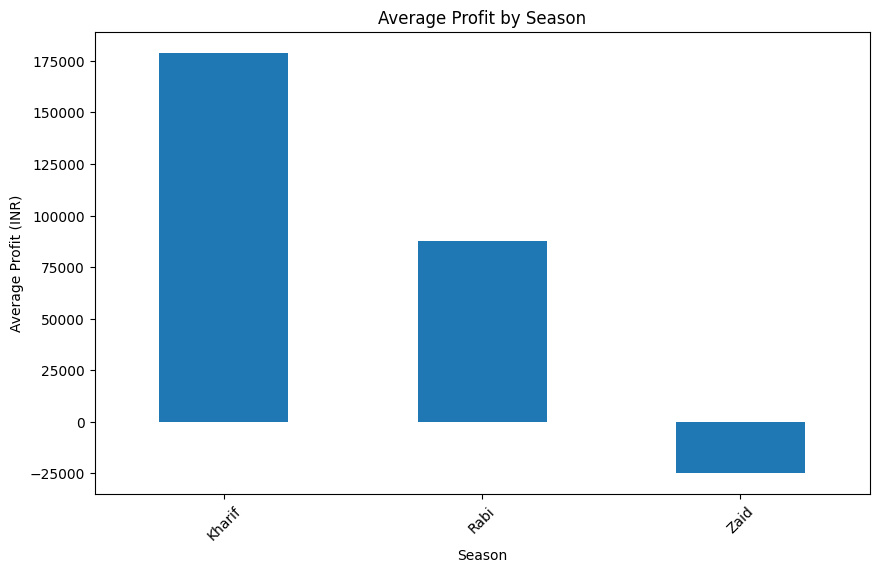

In [ ]:
plt.figure(figsize=(10,6))

season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
economic_summary = df.groupby("Season").agg({
    "Market_Price_INR_Tonne": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean"
}).round(2)

economic_summary

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


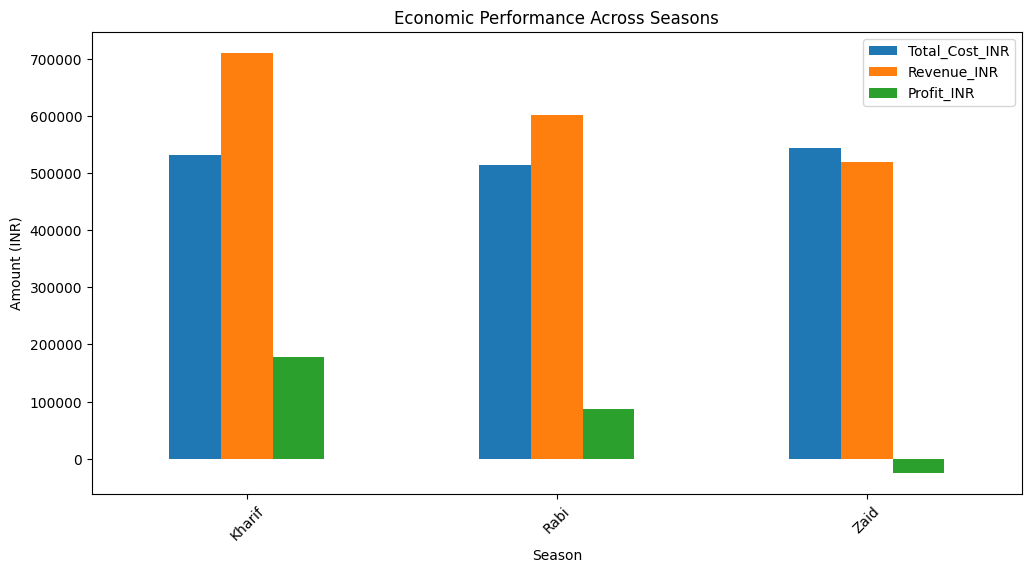

In [ ]:
economic_summary[[
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
rainfall_season = df.groupby("Season")["Rainfall_mm"].mean()

print(rainfall_season)

Season
Kharif    852.084205
Rabi      436.000124
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


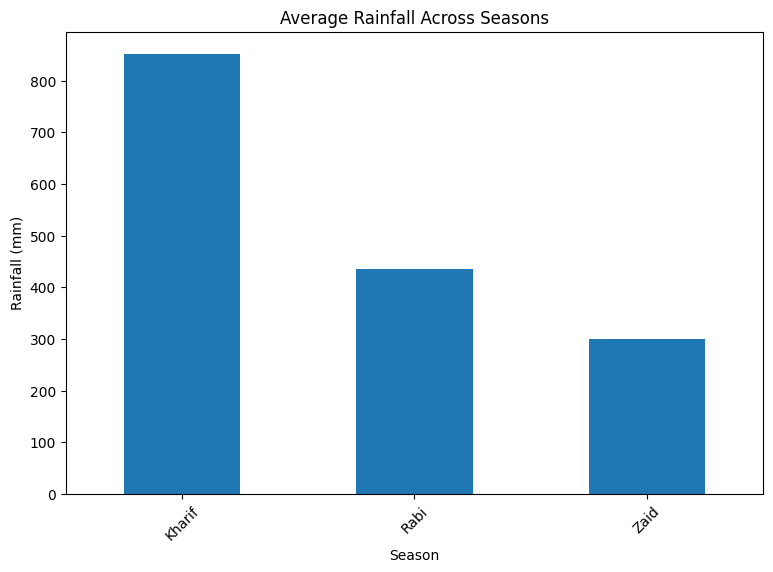

In [ ]:
plt.figure(figsize=(9,6))

rainfall_season.plot(kind="bar")

plt.title("Average Rainfall Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.xticks(rotation=45)
plt.show()

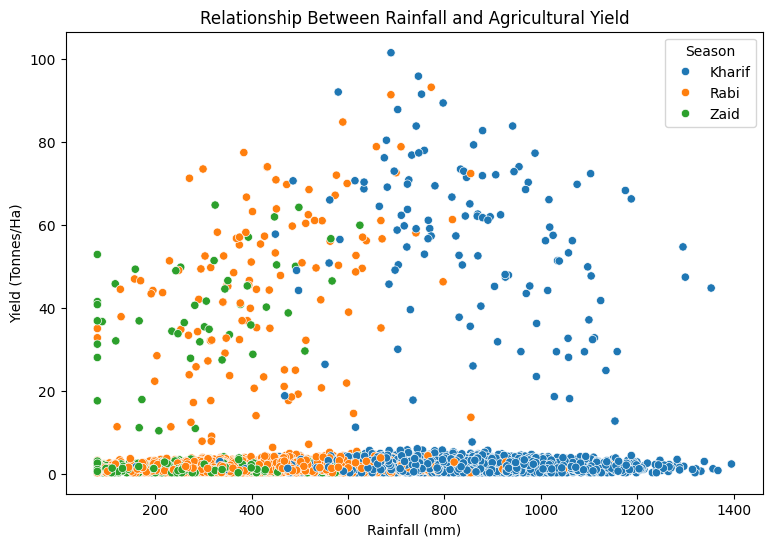

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [ ]:
rainfall_yield_corr = df[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr()

rainfall_yield_corr

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030853
Yield_Tonnes_Ha,0.030853,1.000000


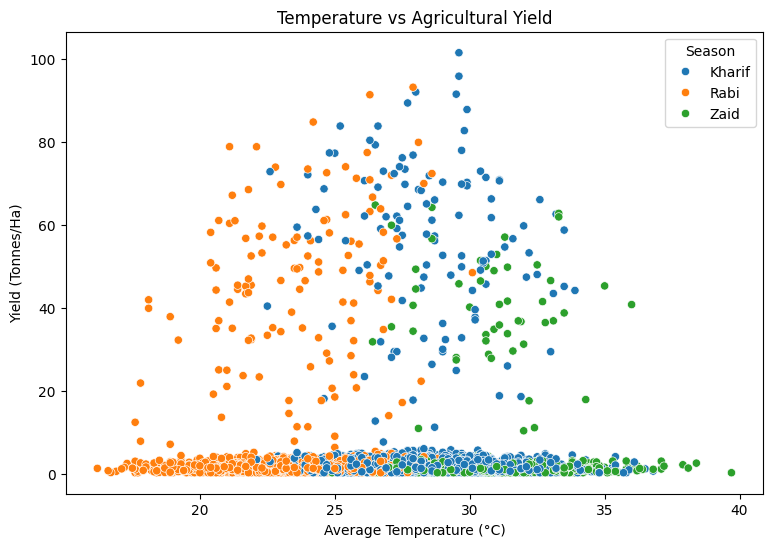

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

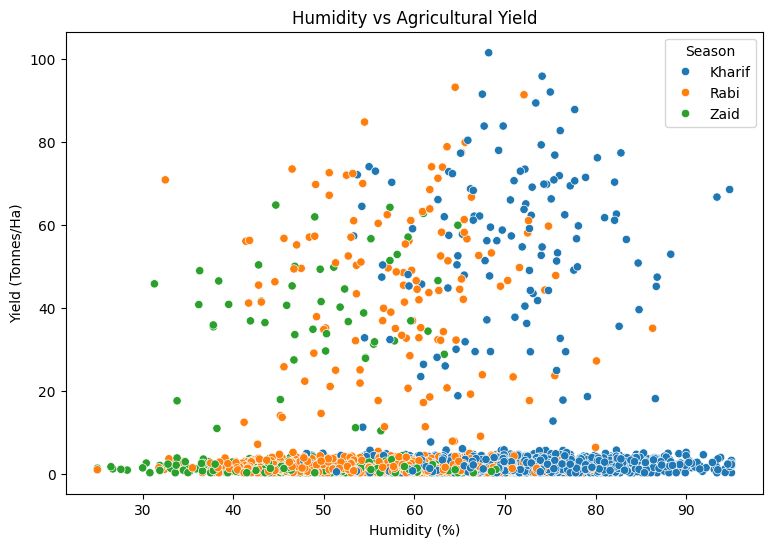

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Humidity_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Humidity vs Agricultural Yield")
plt.xlabel("Humidity (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [ ]:
soil_summary = df.groupby("Season").agg({
    "Soil_pH": "mean",
    "Soil_Moisture_pct": "mean",
    "Nitrogen_kg_ha": "mean",
    "Phosphorus_kg_ha": "mean",
    "Potassium_kg_ha": "mean"
}).round(2)

soil_summary

,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,
Kharif,6.73,31.20,120.02,58.10,105.30
Rabi,6.67,24.05,120.40,57.31,103.93
Zaid,6.69,19.17,120.53,58.13,105.42


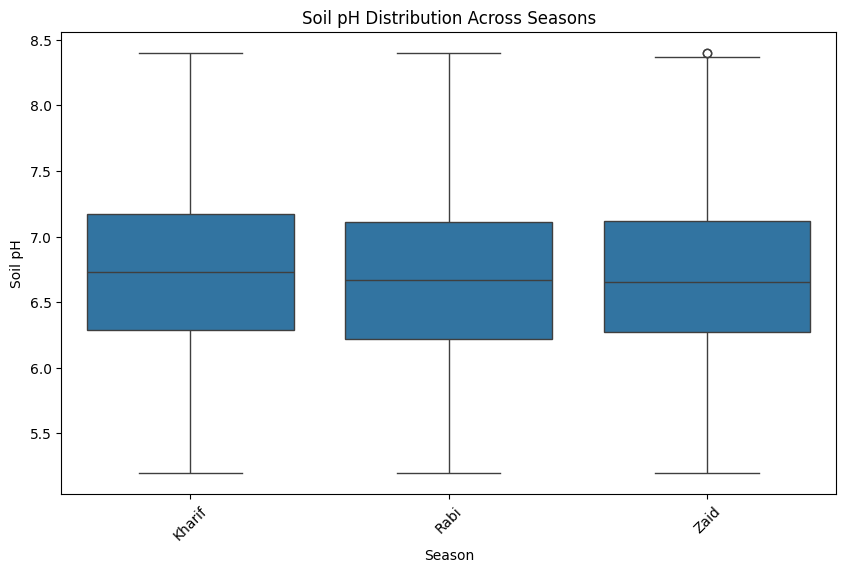

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Soil_pH"
)

plt.title("Soil pH Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil pH")

plt.xticks(rotation=45)
plt.show()

In [ ]:
fertilizer_summary = df.groupby("Season")["Fertilizer_kg_ha"].mean()

print(fertilizer_summary)

Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64


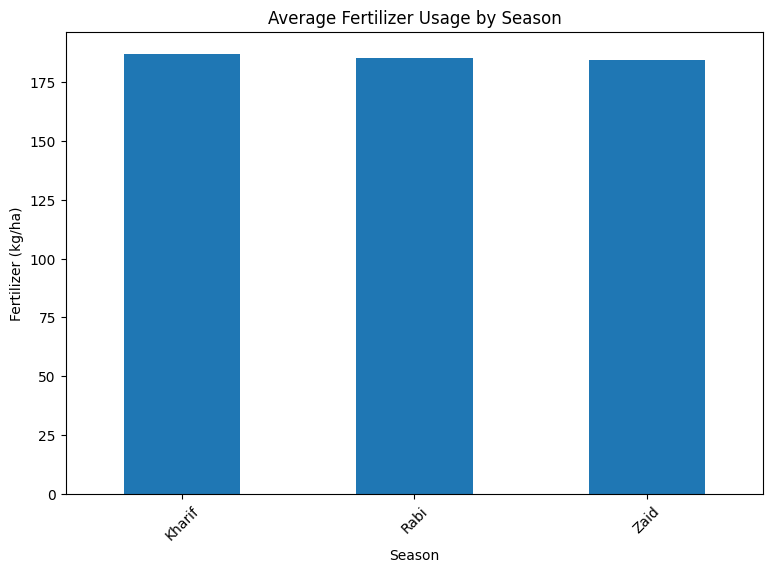

In [ ]:
plt.figure(figsize=(9,6))

fertilizer_summary.plot(kind="bar")

plt.title("Average Fertilizer Usage by Season")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
irrigation_counts = pd.crosstab(
    df["Season"],
    df["Irrigation_Method"]
)

irrigation_counts

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


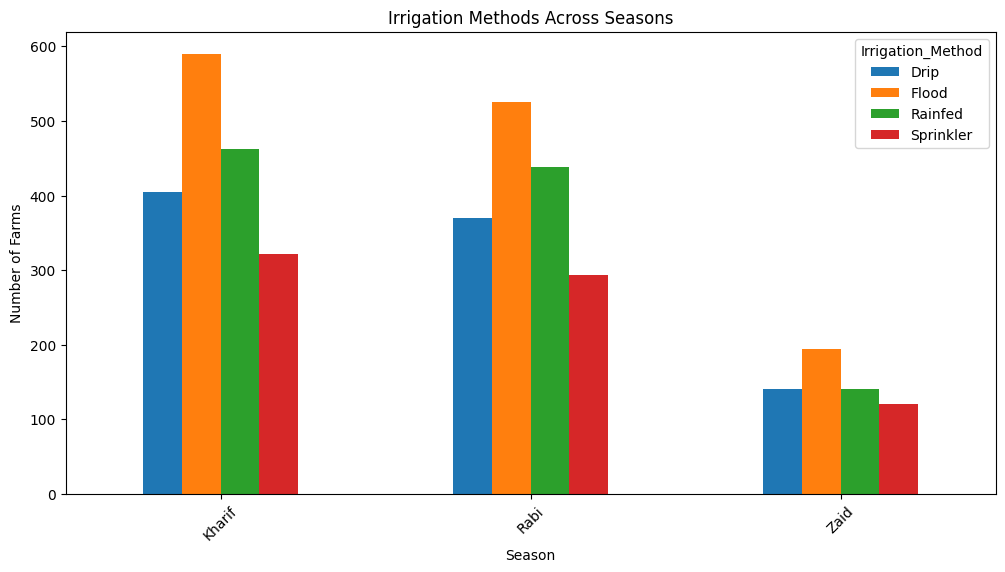

In [ ]:
irrigation_counts.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Irrigation Methods Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.xticks(rotation=45)
plt.show()

In [ ]:
water_summary = df.groupby("Season").agg({
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


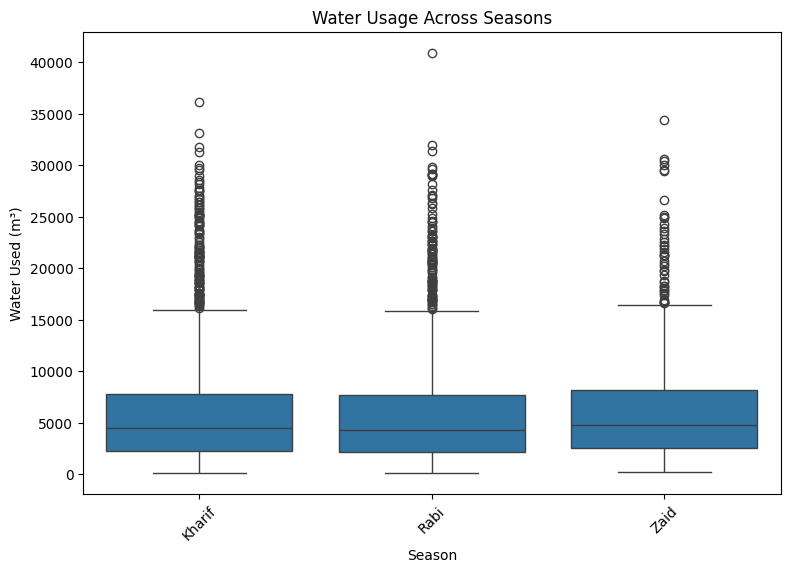

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Water_Used_m3"
)

plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
water_efficiency = (
    df.groupby("Season")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

print(water_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


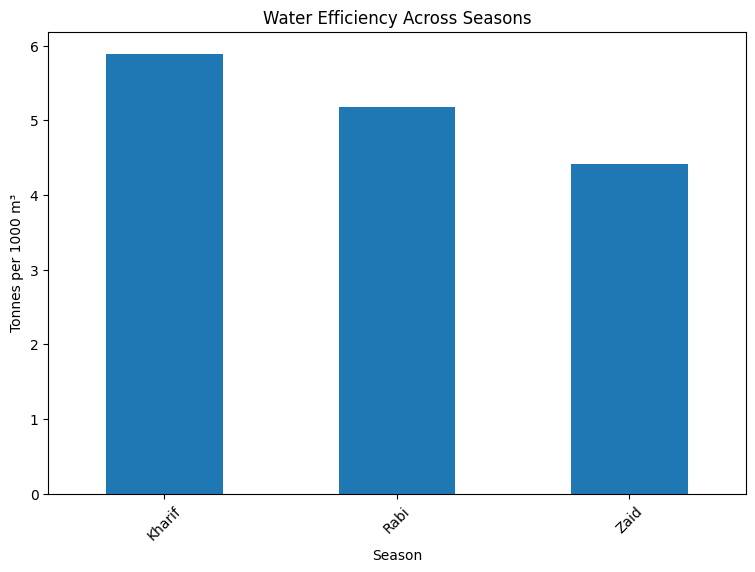

In [ ]:
plt.figure(figsize=(9,6))

water_efficiency.plot(kind="bar")

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.xticks(rotation=45)
plt.show()

In [ ]:
disease_risk = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print(disease_risk)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


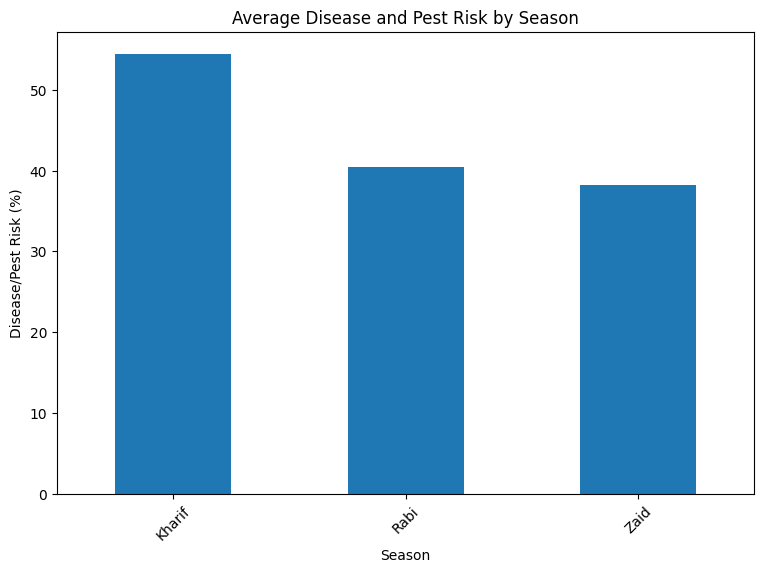

In [ ]:
plt.figure(figsize=(9,6))

disease_risk.plot(kind="bar")

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")

plt.xticks(rotation=45)
plt.show()

In [ ]:
crop_summary = df.groupby("Crop").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean"
}).round(2)

crop_summary.sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3
Crop,,,,
Sugarcane,46.94,392.41,817187.99,13897.70
Maize,2.72,21.78,-83978.33,4377.78
Rice,2.44,19.29,-102213.50,10920.22
Wheat,2.11,16.85,-123398.34,4054.40
Chilli,1.54,12.38,750878.34,4577.47
Groundnut,1.32,9.66,44858.12,3459.54
Cotton,1.23,9.40,124546.92,5410.86
Pulses,0.92,7.40,-4238.05,2833.67


In [ ]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


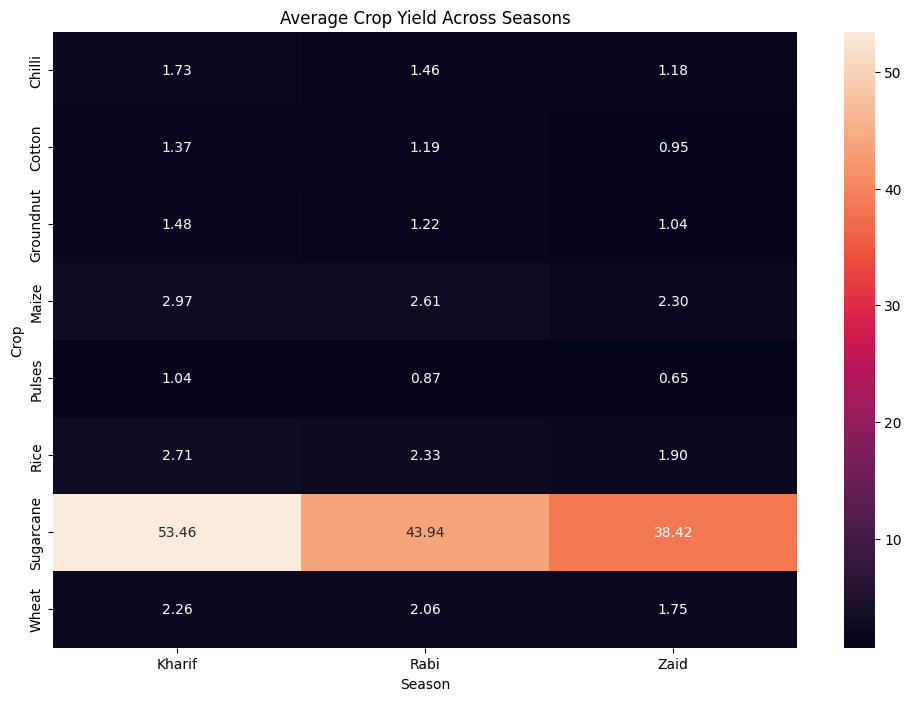

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

In [ ]:
state_summary = df.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean"
}).round(2)

state_summary.sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3
State,,,,
Punjab,6.12,52.23,136025.64,6565.92
Karnataka,5.73,47.73,119422.34,6414.33
Gujarat,5.70,48.33,117568.24,6142.50
Telangana,5.08,39.25,108829.62,5801.83
Maharashtra,5.03,43.98,135428.86,5968.08
Madhya Pradesh,5.03,37.56,86840.76,5663.92
Tamil Nadu,4.90,40.84,117744.75,5775.22
Andhra Pradesh,4.65,36.91,73453.53,6058.38


In [ ]:
top_states = state_summary.sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
).head(10)

top_states

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3
State,,,,
Punjab,6.12,52.23,136025.64,6565.92
Karnataka,5.73,47.73,119422.34,6414.33
Gujarat,5.70,48.33,117568.24,6142.50
Telangana,5.08,39.25,108829.62,5801.83
Maharashtra,5.03,43.98,135428.86,5968.08
Madhya Pradesh,5.03,37.56,86840.76,5663.92
Tamil Nadu,4.90,40.84,117744.75,5775.22
Andhra Pradesh,4.65,36.91,73453.53,6058.38


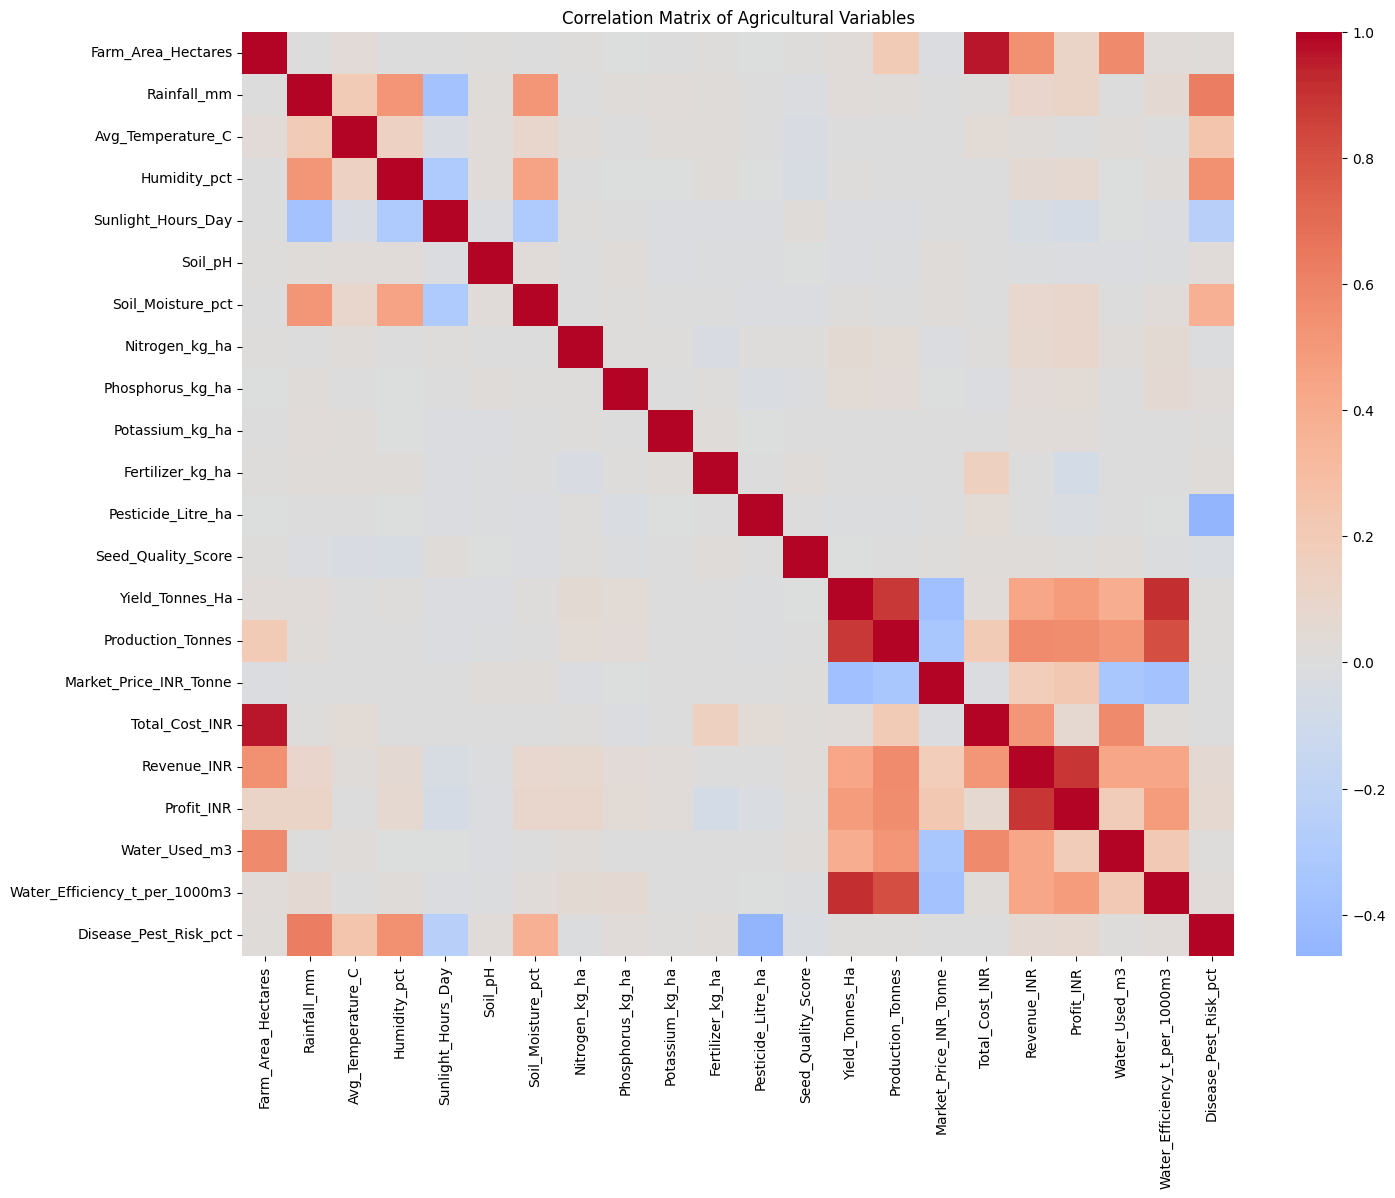

In [ ]:
numeric_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

In [ ]:
yield_correlations = (
    correlation["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

print(yield_correlations)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Rainfall_mm                      0.030853
Total_Cost_INR                   0.030814
Farm_Area_Hectares               0.030188
Disease_Pest_Risk_pct            0.013490
Humidity_pct                     0.011277
Soil_Moisture_pct                0.010210
Avg_Temperature_C                0.009349
Potassium_kg_ha                  0.003836
Fertilizer_kg_ha                 0.000562
Seed_Quality_Score              -0.006737
Pesticide_Litre_ha              -0.007650
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020664
Market_Price_INR_Tonne          -0.384307
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
profit_correlations = (
    correlation["Profit_INR"]
    .sort_values(ascending=False)
)

print(profit_correlations)

Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.489822
Water_Efficiency_t_per_1000m3    0.489487
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.108104
Soil_Moisture_pct                0.091757
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


In [16]:
# ==========================================
# STEP 34: ANOVA TEST FOR SEASONAL YIELD
# ==========================================

from scipy import stats

# Remove missing yield values
anova_df = df[["Season", "Yield_Tonnes_Ha"]].dropna()

# Get the seasons
seasons = anova_df["Season"].unique()

print("Seasons:", seasons)

# Create a separate yield group for each season
season_groups = []

for season in seasons:
    group = anova_df[
        anova_df["Season"] == season
    ]["Yield_Tonnes_Ha"]

    season_groups.append(group)

# Perform one-way ANOVA
anova_result = stats.f_oneway(*season_groups)

print("F-statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

Seasons: ['Kharif' 'Rabi' 'Zaid']
F-statistic: 1.4579589466621523
P-value: 0.23283549440109827


In [17]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print("There is a statistically significant difference in yield across seasons.")
else:
    print("There is no statistically significant difference in yield across seasons.")

There is no statistically significant difference in yield across seasons.


In [18]:
Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_bound) |
    (df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Number of yield outliers:", len(outliers))

Number of yield outliers: 302


In [19]:
outliers[
    [
        "Farm_ID",
        "State",
        "District",
        "Crop",
        "Season",
        "Yield_Tonnes_Ha"
    ]
].head(20)

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,36.69
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,62.58
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,33.55
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,49.52
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,70.23
113,SF10114,Tamil Nadu,Rajkot,Sugarcane,Rabi,58.06
132,SF10133,Telangana,Warangal,Sugarcane,Kharif,29.47
154,SF10155,Telangana,Ludhiana,Sugarcane,Kharif,47.88
155,SF10156,Madhya Pradesh,Guntur,Sugarcane,Kharif,62.09
164,SF10165,Telangana,Guntur,Sugarcane,Rabi,36.91


In [20]:
final_seasonal_analysis = df.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Temperature_C=("Avg_Temperature_C", "mean"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

final_seasonal_analysis

,Farms,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,
Kharif,1779,852.08,28.45,5.64,46.31,178914.65,6102.20,5.89,54.47
Rabi,1627,436.00,23.49,5.08,41.49,87689.47,5846.99,5.19,40.48
Zaid,594,299.42,31.04,4.67,38.89,-24804.82,6419.89,4.41,38.22


In [21]:
best_yield_season = (
    final_seasonal_analysis["Avg_Yield_Tonnes_Ha"]
    .idxmax()
)

best_profit_season = (
    final_seasonal_analysis["Avg_Profit_INR"]
    .idxmax()
)

best_water_efficiency_season = (
    final_seasonal_analysis["Avg_Water_Efficiency"]
    .idxmax()
)

lowest_disease_risk_season = (
    final_seasonal_analysis["Avg_Disease_Risk"]
    .idxmin()
)

print("Best season for average yield:", best_yield_season)
print("Best season for average profit:", best_profit_season)
print("Best season for water efficiency:", best_water_efficiency_season)
print("Lowest disease/pest risk season:", lowest_disease_risk_season)

Best season for average yield: Kharif
Best season for average profit: Kharif
Best season for water efficiency: Kharif
Lowest disease/pest risk season: Zaid


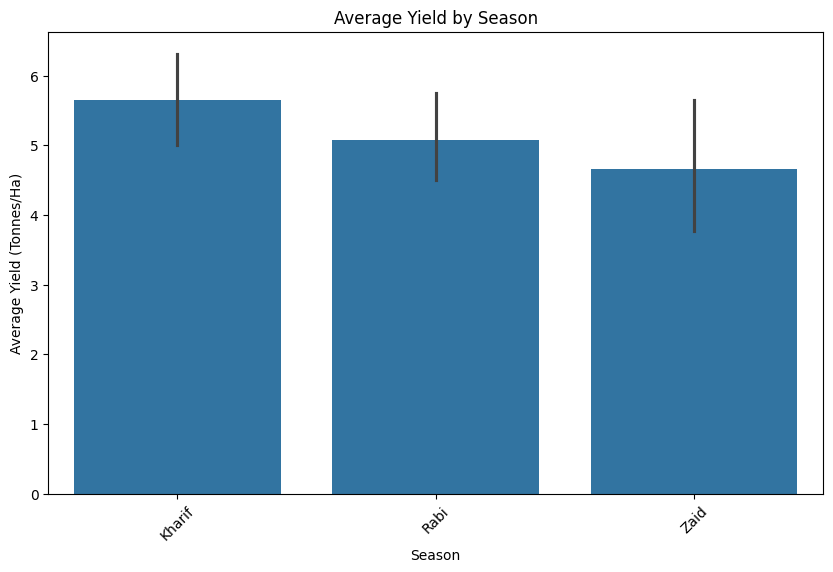

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.show()

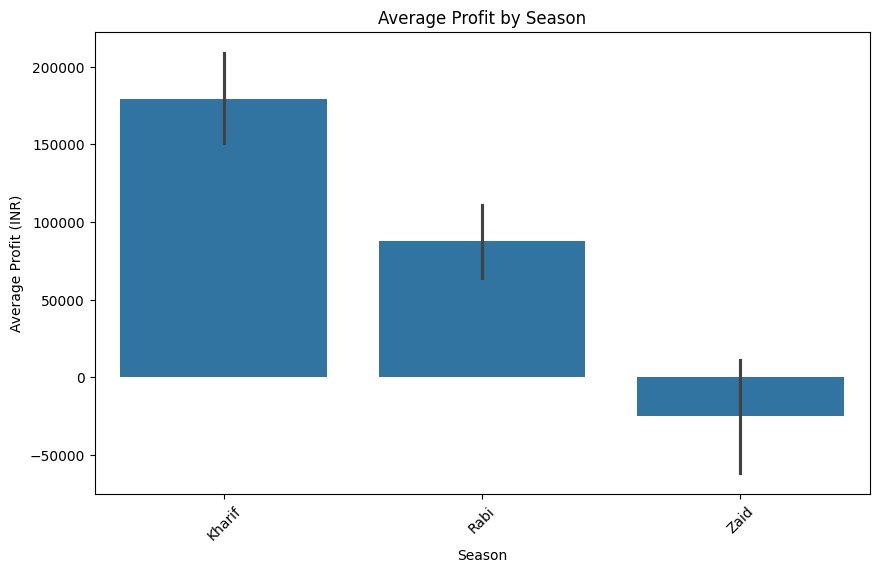

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean"
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.xticks(rotation=45)
plt.show()

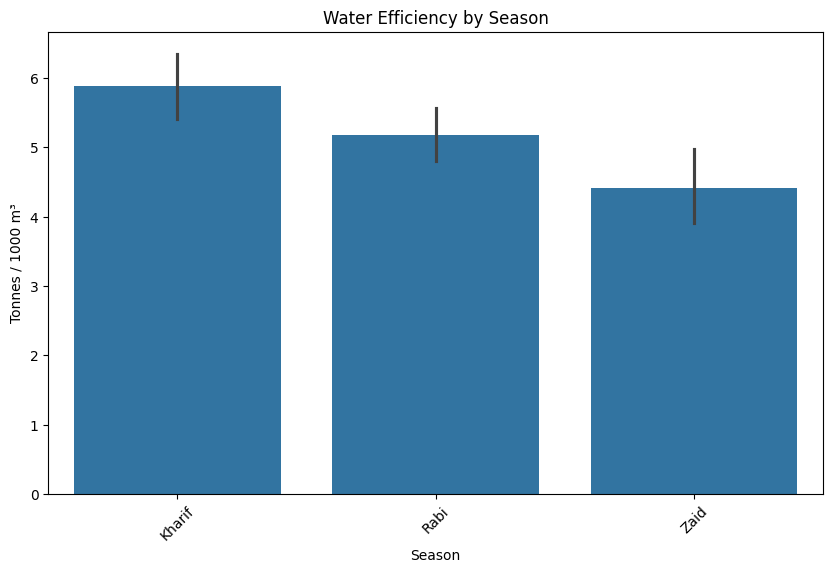

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean"
)

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes / 1000 m³")

plt.xticks(rotation=45)
plt.show()

In [25]:
print("======================================")
print("KEY SEASONAL FINDINGS")
print("======================================")

print(
    "Highest average yield season:",
    final_seasonal_analysis["Avg_Yield_Tonnes_Ha"].idxmax()
)

print(
    "Lowest average yield season:",
    final_seasonal_analysis["Avg_Yield_Tonnes_Ha"].idxmin()
)

print(
    "Highest average profit season:",
    final_seasonal_analysis["Avg_Profit_INR"].idxmax()
)

print(
    "Lowest average profit season:",
    final_seasonal_analysis["Avg_Profit_INR"].idxmin()
)

print(
    "Highest water efficiency season:",
    final_seasonal_analysis["Avg_Water_Efficiency"].idxmax()
)

print(
    "Lowest disease/pest risk season:",
    final_seasonal_analysis["Avg_Disease_Risk"].idxmin()
)

KEY SEASONAL FINDINGS
Highest average yield season: Kharif
Lowest average yield season: Zaid
Highest average profit season: Kharif
Lowest average profit season: Zaid
Highest water efficiency season: Kharif
Lowest disease/pest risk season: Zaid


# Conclusion

The Seasonal Agriculture Performance Analysis was conducted to understand
how agricultural performance varies across different seasons.

The analysis examined seasonal differences in:

- Agricultural yield
- Production
- Profit and revenue
- Rainfall and temperature
- Soil conditions
- Fertilizer and pesticide usage
- Irrigation and water consumption
- Water efficiency
- Disease and pest risk

The analysis identified differences in agricultural performance across
seasons. Relationships between environmental conditions, resource usage,
and agricultural outcomes were also investigated using correlation analysis,
visualizations, and statistical testing.

The findings provide evidence-based insights that can support better
seasonal agricultural planning and identify areas requiring further
investigation.